<a href="https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print('Comment notation:')
print('#: description of what is being done')
print('##: question')
print('###: problem')
print('####: task')

print("colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb")

Comment notation:
#: description of what is being done
##: question
###: problem
####: task
colab link: https://colab.research.google.com/github/lia-lubit/DESIxSO/blob/main/forecasting.ipynb


In [2]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
import ipyparallel as ipp

# scientific stack
import numpy as np
import jax.numpy as jnp
import scipy
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.integrate import simpson

# cosmology
import astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
import classy
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# inference / sampling
import cobaya
from cobaya.run import run as cobaya_run
from cobaya.likelihood import Likelihood
from cobaya.model import get_model
#from cobaya_utilities import tools -- this wont import, but I don't use it at the momment anyway
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples

# notebook only (remove if this becomes a .py module)
%matplotlib inline

In [3]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import build_covariance_from_data_old
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_correlation_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import instrument_Pk2D

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import SO_x_DESI_Likelihood_A_s_version
from functions_and_classes import SO_x_DESI_Likelihood_w_emulator
from functions_and_classes import SO_x_DESI_Likelihood_sigma8_version
from functions_and_classes import Pk2DTimer

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [4]:
# data

# DESI-HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DESI Lens Data

DESI_lens_data = np.loadtxt("data/des_nz_gamma.txt")

DESI_lens_data = DESI_lens_data[7:]  # removes the first 7 values (headers)
DESI_lens_data = DESI_lens_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DESI_lens_z    = DESI_lens_data[:, 0]
DESI_lens_nz_a = DESI_lens_data[:, 1]
DESI_lens_nz_b = DESI_lens_data[:, 2]
DESI_lens_nz_c = DESI_lens_data[:, 3]
DESI_lens_nz_d = DESI_lens_data[:, 4]
DESI_lens_nz_e = DESI_lens_data[:, 5]

DESI_lens_data = np.column_stack((DESI_lens_z, DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

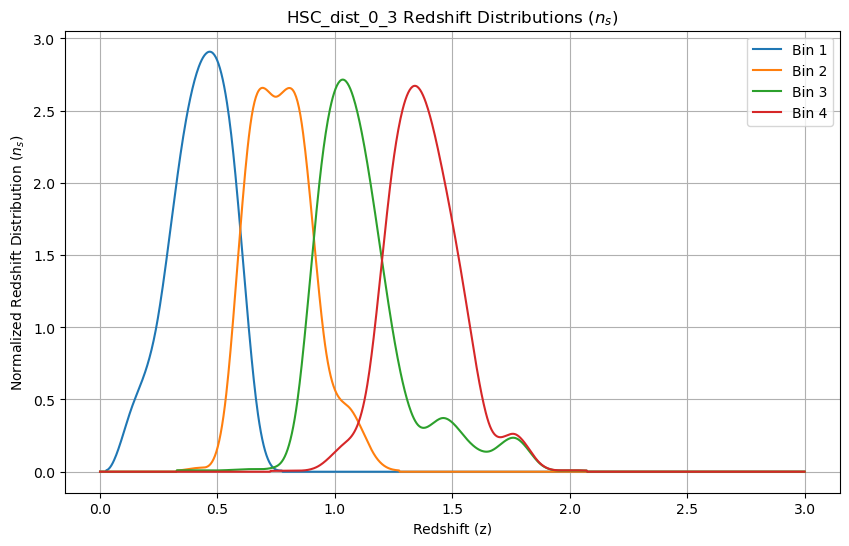

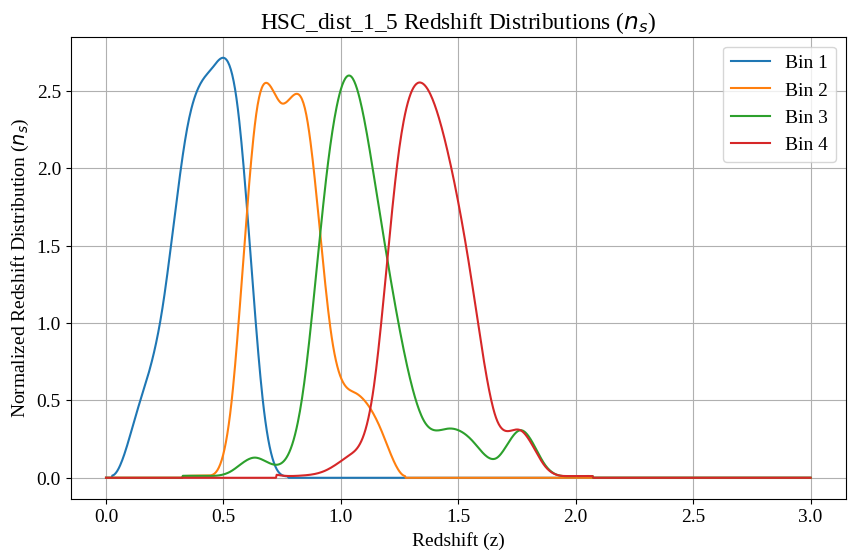

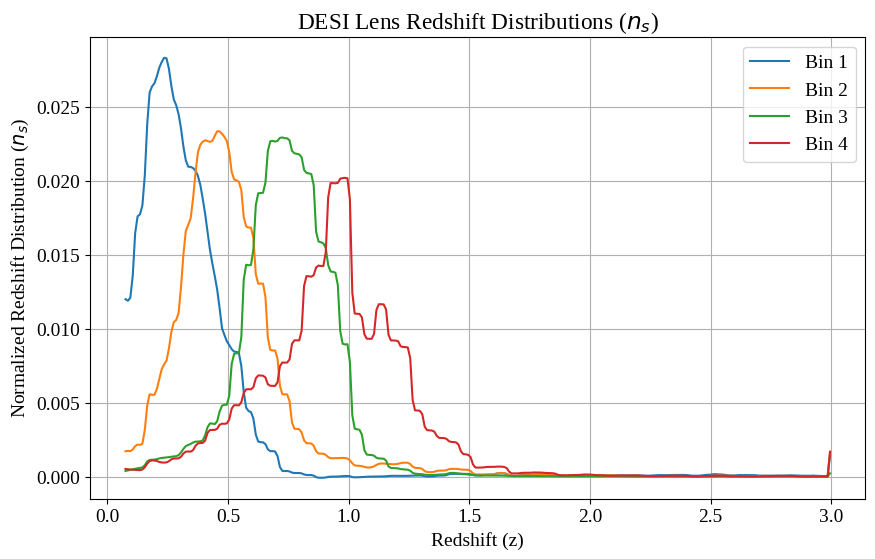

In [5]:
# graph HSC source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='Bin 4')
#plt.plot(DESI_lens_z, DESI_lens_nz_e, label='Bin 5')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DESI Lens Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

Mean redshifts for DESI lens bins:
  Lens Bin 1: 0.343
  Lens Bin 2: 0.522
  Lens Bin 3: 0.742
  Lens Bin 4: 0.936


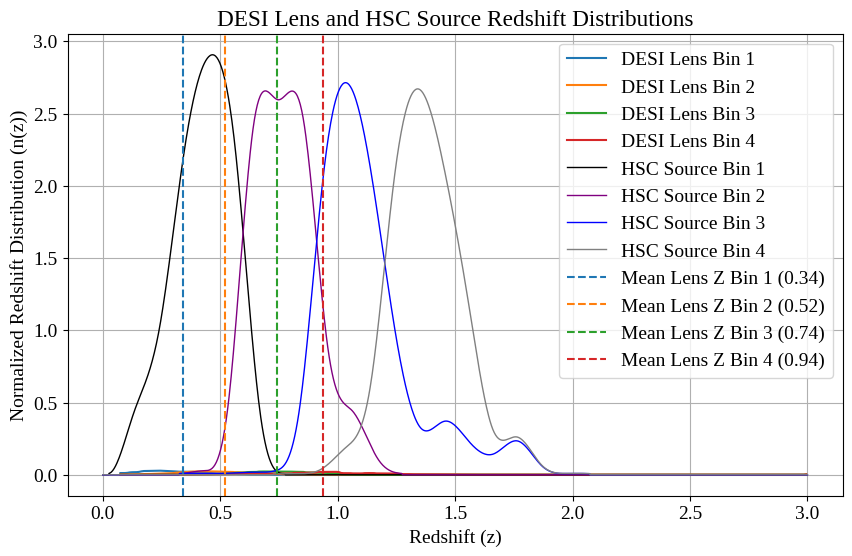

In [6]:
# calculate mean lens redshifts for each DESI lens bin
mean_desi_lens_redshifts = []

# DESI_lens_data contains z in col 0, then nz_a, nz_b, nz_c, nz_d in cols 1-4
nz_arrays_desi = [DESI_lens_nz_a, DESI_lens_nz_b, DESI_lens_nz_c, DESI_lens_nz_d]
z_lens_grid = DESI_lens_data[:, 0]

for i, n_lens_i in enumerate(nz_arrays_desi):
    if np.sum(n_lens_i) == 0:
        mean_desi_lens_redshifts.append(np.nan)
    else:
        z_l_i = scipy.integrate.trapezoid(z_lens_grid * n_lens_i, z_lens_grid) / scipy.integrate.trapezoid(n_lens_i, z_lens_grid)
        mean_desi_lens_redshifts.append(z_l_i)

print("Mean redshifts for DESI lens bins:")
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    print(f"  Lens Bin {i+1}: {z_l_i:.3f}")

# plot DESI lens distributions and the first HSC_dist_0_3 source distribution
plt.figure(figsize=(10, 6))
plt.plot(DESI_lens_z, DESI_lens_nz_a, label='DESI Lens Bin 1')
plt.plot(DESI_lens_z, DESI_lens_nz_b, label='DESI Lens Bin 2')
plt.plot(DESI_lens_z, DESI_lens_nz_c, label='DESI Lens Bin 3')
plt.plot(DESI_lens_z, DESI_lens_nz_d, label='DESI Lens Bin 4')

plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='HSC Source Bin 1', linestyle='-', linewidth=1, color='black')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='HSC Source Bin 2', linestyle='-', linewidth=1, color='purple')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='HSC Source Bin 3', linestyle='-', linewidth=1, color='blue')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='HSC Source Bin 4', linestyle='-', linewidth=1, color='gray')

# Add vertical lines for mean lens redshifts
for i, z_l_i in enumerate(mean_desi_lens_redshifts):
    plt.axvline(x=z_l_i, color=f'C{i}', linestyle='--', label=f'Mean Lens Z Bin {i+1} ({z_l_i:.2f})')

plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution (n(z))')
plt.title('DESI Lens and HSC Source Redshift Distributions')
plt.legend()
plt.grid(True)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Liberation Serif'
plt.rcParams['font.size'] = 14
plt.show()

In [ ]:
# CCL
print('CCL cosmology parameters:')
print('Omega_c: the density fraction at z=0 of CDM.')
print('Omega_b: the density fraction at z=0 of baryons.')
print('h: the Hubble constant in units of 100 k⁢m/s/M⁢p⁢c.')
print('Omega_k: the curvature density fraction at 𝑧 =0.')
print('Omega_g: the density of radiation (not including massless neutrinos.')
print('w0: first order term of the dark energy equation of state.')
print('wa: second order term of the dark energy equation of state.')

In [ ]:
# CCL cosmolgoies

# сosmology -- standard CCL + DESI waw0
h = 0.6674
w0 = -0.752
wa = -0.86
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
w0wa_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, w0=w0, wa=wa, transfer_function='boltzmann_camb')

# сosmology -- standard CCL + DESI curved h and Omega_k
h = 0.6850
Om0 = 0.3191
Omega_c = 0.27
Omega_b = 0.045
sigma8 = 0.8
A_s = 2.105e-9
n_s = 0.96
Omega_k = 2.3e-3
curved_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

# cosmology -- standard CCL + flat LCDM
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
A_s = 2.105e-9
Omega_c = 0.27
flat_LCDM_cosmology = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s = A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

In [ ]:
# plot angular power spectra

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['GG'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['GL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CG'])

calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'])

### CosmoPower Emulator

**CosmoPower** is a suite of neural network emulators that can predict power spectra and other parameters. In MCMC, a lot of the computation time is spent calculating power spectra for each proposed set of cosmological parameters. Cosmopower can speed this up.

We'll do some experimenting with CosmoPower and then integrate it with the MCMC.

What we need to do is:
1. Before running the MCMC, train the network on a dataset of power spectra computed using a full Boltzmann solver across a wide range of cosmological parameters, or find a pre-trained model and extrapolate from it to get the spectra we want.
2. Integrate the CosmoPower network into the Cobaya likelihood. That way, during the sampling, instead of recalculating the power spectru at each step, the pre-trained CosmoPower network will rapidly predict the power spectra. This will allow the sampler to explore much more quickly.

We'll need:
1.  **`cosmopower`**: The core library containing the trained emulators.
2.  **`cobaya-cosmopower`**: A Cobaya-specific wrapper that integrates the `cosmopower_cl` likelihood into your Cobaya runs. We'll specify a path to a pre-trained CosmoPower model (`.npz` file) for the desired power spectra (e.g., `cl_TT`, `cl_EE`, `cl_TE`, `cl_phi_phi`). This will repalce our current call to pyccl.

Notes:
1. The emulator has a k-grid but NOT a z-grid. You can dynaically set the z values and run the emulator. Our C_l's are all integrals over the line of sight (over lots of different z's) so we'll need to consider the P(k) at all the z's from here to the start of time. We'll need to figure out if that z range is suitable for all the calculations -- I need to get more into the details of the integrals of C_l's again for the different types of C_l. 
2. The standard CosmoPower uses TensorFlow which is incompatible with other packages we need. Use CosmoPower-Jax instead. (Trust me on this, don't try to make the normal CosmoPower work...)

In [7]:
#import pre-trained P(k) emulators stored in emulator file

lin_emu = CPJ(probe='mpk_lin')
boost_emu = CPJ(probe='mpk_boost')

print('linear P(k) emulator parameters: ', lin_emu.parameters)
print('boost P(k) emulator parameters: ', boost_emu.parameters)

linear P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'z']
boost P(k) emulator parameters:  ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'cmin', 'eta_0', 'z']


In [ ]:
# test new emulator functions for a simple linear power spectrum

# cosmology -- standard CCL + flat LCDM w/A_s
z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
Omega_c = 0.27
A_s = 2.1 * 1e-9
n_s=0.96
flat_LCDM_cosmology2 = ccl.Cosmology(Omega_k = Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s,
                               n_s=n_s, transfer_function='boltzmann_camb')

k_modes = lin_emu.modes

# PyCCL
a = 1.0 / (1.0 + 0.5)
linear_spectrum_ccl = ccl.linear_matter_power(flat_LCDM_cosmology2, k_modes, a)
non_linear_spectrum_ccl = ccl.nonlin_matter_power(flat_LCDM_cosmology2, k_modes, a)

# emulator
linear_Pk = predict_linear_Pk(flat_LCDM_cosmology2, lin_emu, 0.5)
z_grid = np.linspace(0, 10, 50)
Pk2D_full = make_Pk2D(flat_LCDM_cosmology2, linear_emulator = lin_emu, boost_emulator = boost_emu, z_arr = z_grid, cmin=3.13, eta_0=0.68)
non_linear_Pk = Pk2D_full(k=k_modes, a=a)

# plot
fig = plt.figure(figsize=(20, 10))
plt.loglog(k_modes, linear_spectrum_ccl, color='black', linewidth=5, label='Linear CCL (Boltzmann)')
plt.loglog(k_modes, non_linear_spectrum_ccl, color='purple', linewidth=5, label='Nonlinear CCL (Boltzmann)')
plt.loglog(k_modes, linear_Pk, color='blue', linewidth=5, linestyle='--', label='Linear Emulator')
plt.loglog(k_modes, non_linear_Pk, color='green', linewidth=5, linestyle=':', label=r'Nonlinear Emulator')
plt.xlabel(r'$k \quad [h \, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel(r'$P(k) \quad [h^{-3} \, \mathrm{Mpc}^3]$', fontsize=13)
plt.title(f'Matter Power Spectrum Verification at $z = {0.5}$', fontsize=14, pad=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# scaled differences
fig = plt.figure(figsize=(20, 10))
linear_diff = (linear_Pk - linear_spectrum_ccl) / (linear_spectrum_ccl)
non_linear_diff = (non_linear_Pk - non_linear_spectrum_ccl) / (non_linear_spectrum_ccl)
plt.plot(k_modes, linear_diff, color='black', linewidth=5, label='Linear')
plt.plot(k_modes, non_linear_diff, color='purple', linewidth=5, label='Nonlinear')
plt.xlabel(r'$k \quad [h \, \mathrm{Mpc}^{-1}]$', fontsize=13)
plt.ylabel('scaled differences')
plt.title(f'Matter Power Spectrum Verification at $z = {0.5}$', fontsize=14, pad=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.show()

BBKS/sigma8 PyCCL Cosmology Instantiation: 0.0013 seconds


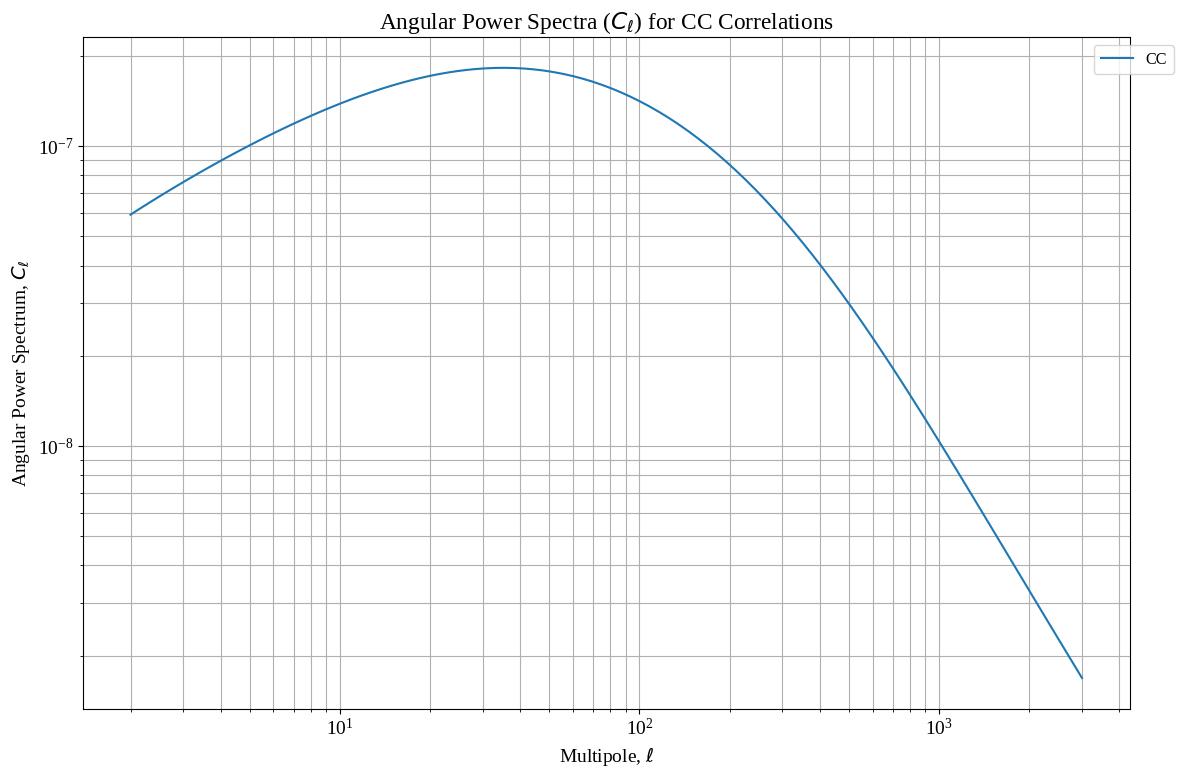

BBKS/sigma8 PyCCL angular_cl Calculation: 0.4689 seconds
CAMB/A_s PyCCL Cosmology Instantiation: 0.0007 seconds


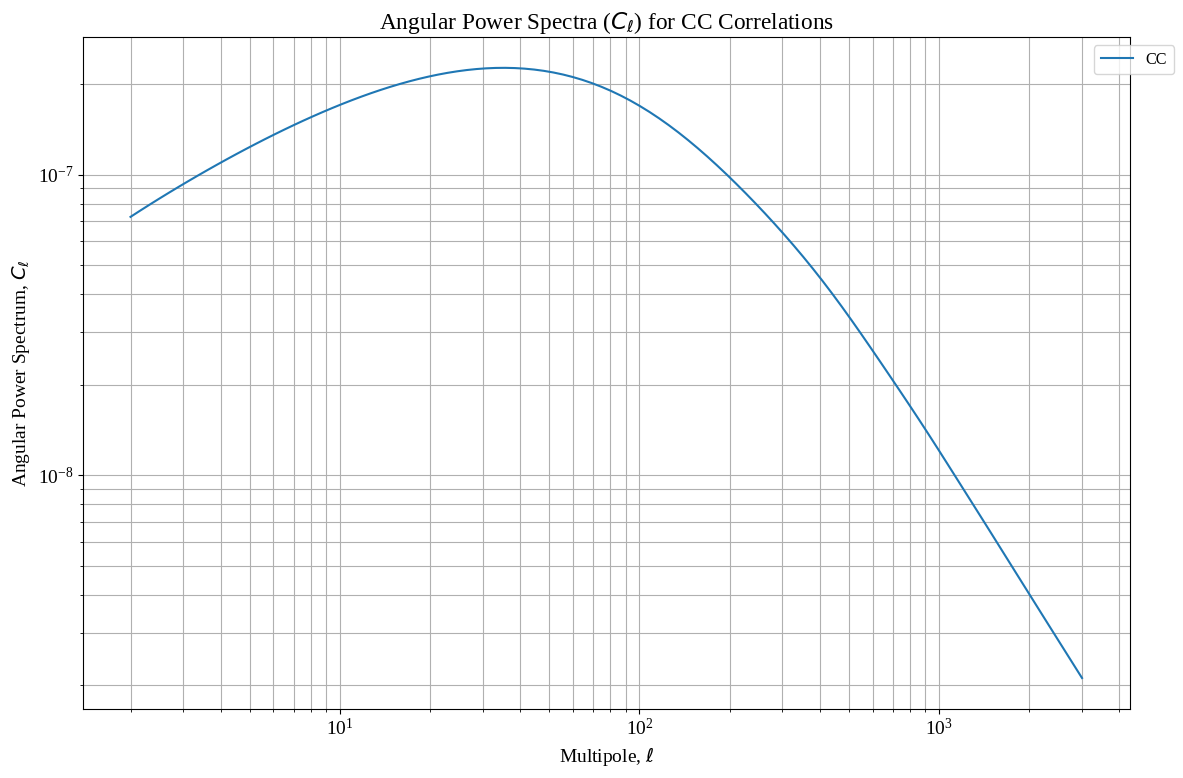

CAMB/A_s PyCCL angular_cl Calculation: 1.3197 seconds
Emulated Pk2D Object Creation: 0.0748 seconds


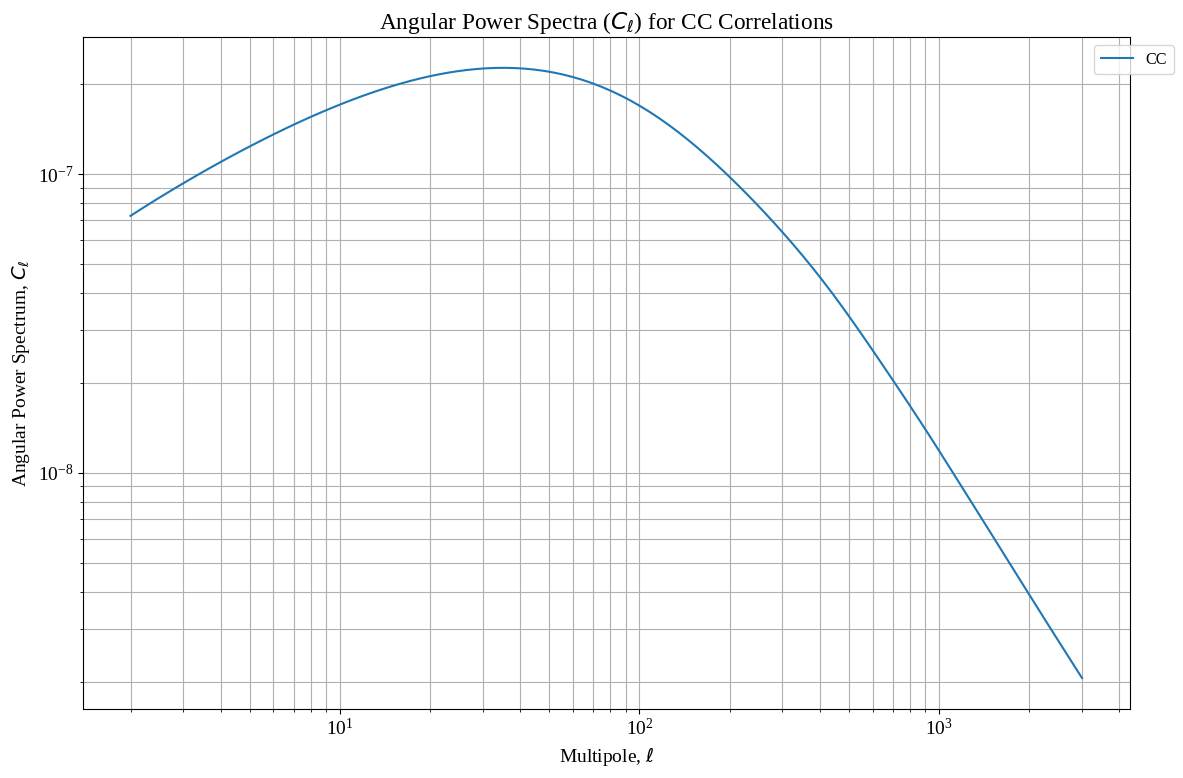

Emulated P(k) angular_cl Calculation: 0.3030 seconds

General Summary
These times all include plotting. In my MCMC I do not actually plot the Cls, so these efficiency comparisons are a little incomplete.
In a later cell I will compare just the creation.
The times and differences vary each run. The final two results (see 'bottom line') generally stay between .65-1.0 and .35-.5, respectively.
The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.
This is not lsot time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.
Total BBKS (sigma8) PyCCL time: 0.4701 seconds (Cosmology Init + angular_cl)
Total CAMB (A_s) PyCCL time: 1.3203 seconds (Cosmology Init + angular_cl)
Total Emulated PyCCL time: 0.3785 seconds (Cosmology Init + Pk2D Creation + angular_cl)
Total Emulated P(k) angular_cl time was 0.65 times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.
Total Emulated P(k) angular_c

In [18]:
# test timing and accuracy w/plots

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, # Use A_s here
    n_s=n_s, transfer_function='bbks'
)
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'])
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb'
)
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'])
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

start_time_emu_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CC'],
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# results
print("")
print("General Summary")
print("These times all include plotting. In my MCMC I do not actually plot the Cls, so these efficiency comparisons are a little incomplete.")
print("In a later cell I will compare just the creation.")
print("The times and differences vary each run. The final two results (see 'bottom line') generally stay between .65-1.0 and .35-.5, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lsot time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

In [21]:
# test timing and accuracy w/o plots

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, n_s=n_s, transfer_function='bbks')
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no')
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb')
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
standard_Cl_CL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no')
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

#timed_Pk2D_object = instrument_Pk2D(Pk2D_full_timed)

start_time_emu_cl = time.time()
emulator_Cl_CL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['CL'],
    plot = 'no',
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# find percent of PyCCL runtime spent calling Pk2D
#timing_info = timed_Pk2D_object.get_timing_info()
#total_Pk2D_call_time_s = timing_info['total_time_ns']
#Pk2D_call_count = timing_info['call_count']
#print(f"Number of Pk2D.__call__ invocations: {Pk2D_call_count}")
#print(f"Total time spent in Pk2D.__call__ method: {total_Pk2D_call_time_s:.6f} seconds")

# separate Pk2D call
#start_time_call_Pk2D = time.time()
#temp_Pk2D = Pk2D_full_timed
#end_time_call_Pk2D = time.time()
#time_call_Pk2D = end_time_call_Pk2D - start_time_call_Pk2D
#print(f"Time to call Pk2D outside of PyCCL: {time_call_Pk2D:.4f} seconds")

# results
print("")
print("General Summary")
print("The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")
#print(f"The time to call the Pk2D object ONCE was {time_call_Pk2D / time_emu_cl} times that of the total PyCCL emulator Cl calculation (excluding emulator building).")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

BBKS/sigma8 PyCCL Cosmology Instantiation: 0.0007 seconds
BBKS/sigma8 PyCCL angular_cl Calculation: 0.1822 seconds
CAMB/A_s PyCCL Cosmology Instantiation: 0.0007 seconds
CAMB/A_s PyCCL angular_cl Calculation: 1.0381 seconds
Emulated Pk2D Object Creation: 0.0709 seconds
Emulated P(k) angular_cl Calculation: 0.0239 seconds

General Summary
The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.
The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.
This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.
Total BBKS (sigma8) PyCCL time: 0.1829 seconds (Cosmology Init + angular_cl)
Total CAMB (A_s) PyCCL time: 1.0388 seconds (Cosmology Init + angular_cl)
Total Emulated PyCCL time: 0.0955 seconds (Cosmology Init + Pk2D Creation + angular_cl)
Total Emulated P(k) angular_cl calculation time w

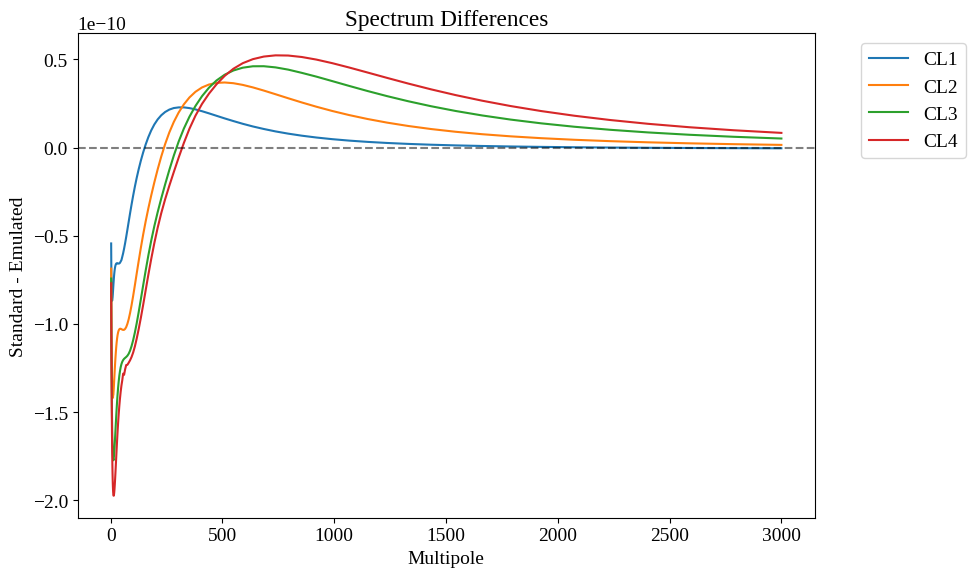

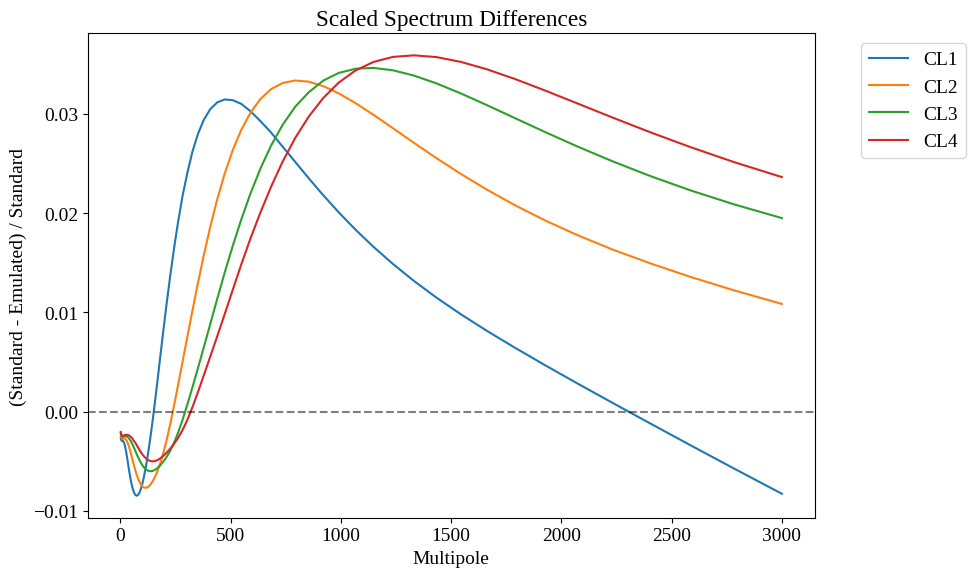

In [23]:
# compare the Cl's

ell_values = np.logspace(np.log10(2), np.log10(3000), 100)

# straight diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_CL.keys()):
    diff = standard_Cl_CL[key] - emulator_Cl_CL[key]
    plt.plot(ell_values, diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("Standard - Emulated")
plt.title("Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# scaled diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_CL.keys()):
    diff = standard_Cl_CL[key] - emulator_Cl_CL[key]
    scaled_diff = diff / standard_Cl_CL[key]
    plt.plot(ell_values, scaled_diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("(Standard - Emulated) / Standard")
plt.title("Scaled Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# test timing and accuracy w/o plots -- LL

# standard PyCCL w/sigma8
start_time_ccl1_init = time.time()

z_star = 1100.0
Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27
sigma8 = 0.8

flat_LCDM_cosmology1_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, sigma8=sigma8, n_s=n_s, transfer_function='bbks')
end_time_ccl1_init = time.time()
time_ccl1_init = end_time_ccl1_init - start_time_ccl1_init
print(f"BBKS/sigma8 PyCCL Cosmology Instantiation: {time_ccl1_init:.4f} seconds")

start_time_ccl1_cl = time.time()
calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology1_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no')
end_time_ccl1_cl = time.time()
time_ccl1_cl = end_time_ccl1_cl - start_time_ccl1_cl
print(f"BBKS/sigma8 PyCCL angular_cl Calculation: {time_ccl1_cl:.4f} seconds")

# standard PyCCL w/A_s
start_time_ccl2_init = time.time()

Om0 = 0.3027   # matter density
H0 = 68.17     # Hubble [km/s/Mpc]
h = 0.6817
Ode0 = 1 - Om0 # dark energy density
A_s = 2.1e-9 # Using A_s, consistent with emulator input
Omega_k = 0
Omega_b = 0.045
n_s=0.96
Omega_c = 0.27

flat_LCDM_cosmology2_timed = ccl.Cosmology(
    Omega_k=Omega_k, Omega_c=Omega_c, Omega_b=Omega_b, h=h, A_s=A_s, # Use A_s here
    n_s=n_s, transfer_function='boltzmann_camb')
end_time_ccl2_init = time.time()
time_ccl2_init = end_time_ccl2_init - start_time_ccl2_init
print(f"CAMB/A_s PyCCL Cosmology Instantiation: {time_ccl2_init:.4f} seconds")

start_time_ccl2_cl = time.time()
standard_Cl_LL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed, # Use the newly created cosmology object
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no')
end_time_ccl2_cl = time.time()
time_ccl2_cl = end_time_ccl2_cl - start_time_ccl2_cl
print(f"CAMB/A_s PyCCL angular_cl Calculation: {time_ccl2_cl:.4f} seconds")

# emulator
# 20 points spaced evenly in scale factor from z=0 (a=1) to z=5 (a=1/6)
start_time_emu_pk2d = time.time()
a_grid = np.linspace(1/(1+5), 1.0, 20)
z_grid = (1.0 / a_grid) - 1.0

Pk2D_full_timed = make_Pk2D(
    flat_LCDM_cosmology2_timed, # Use the same cosmology to ensure parameter consistency
    linear_emulator=lin_emu,
    boost_emulator=boost_emu,
    z_arr=z_grid,
    cmin=3.13,
    eta_0=0.60
)
end_time_emu_pk2d = time.time()
time_emu_pk2d = end_time_emu_pk2d - start_time_emu_pk2d
print(f"Emulated Pk2D Object Creation: {time_emu_pk2d:.4f} seconds")

#timed_Pk2D_object = instrument_Pk2D(Pk2D_full_timed)

start_time_emu_cl = time.time()
emulator_Cl_LL = calculate_and_plot_Cls(
    cosmology=flat_LCDM_cosmology2_timed,
    lens_data=DESI_lens_data,
    source_data=HSC_dist_0_3,
    correlation_types=['LL'],
    plot = 'no',
    Pk2D_object = Pk2D_full_timed
)
end_time_emu_cl = time.time()
time_emu_cl = end_time_emu_cl - start_time_emu_cl
print(f"Emulated P(k) angular_cl Calculation: {time_emu_cl:.4f} seconds")

# find percent of PyCCL runtime spent calling Pk2D
#timing_info = timed_Pk2D_object.get_timing_info()
#total_Pk2D_call_time_s = timing_info['total_time_ns']
#Pk2D_call_count = timing_info['call_count']
#print(f"Number of Pk2D.__call__ invocations: {Pk2D_call_count}")
#print(f"Total time spent in Pk2D.__call__ method: {total_Pk2D_call_time_s:.6f} seconds")

# separate Pk2D call
#start_time_call_Pk2D = time.time()
#temp_Pk2D = Pk2D_full_timed
#end_time_call_Pk2D = time.time()
#time_call_Pk2D = end_time_call_Pk2D - start_time_call_Pk2D
#print(f"Time to call Pk2D outside of PyCCL: {time_call_Pk2D:.4f} seconds")

# results
print("")
print("General Summary")
print("The times and differences vary slightly each run. The final two results (see 'bottom line') generally stay between .51-.61 and .12-.16, respectively.")
print("The emulator cosmologies use the CAMB solver by necessity, so they are generally more accurate than the BBKs ones.")
print("This is not lost time, as I think I'd use CAMB/CLASS for my analyses anyway, since they are more accurate.")
print(f"Total BBKS (sigma8) PyCCL time: {time_ccl1_init + time_ccl1_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total CAMB (A_s) PyCCL time: {time_ccl2_init + time_ccl2_cl:.4f} seconds (Cosmology Init + angular_cl)")
print(f"Total Emulated PyCCL time: {time_ccl2_init + time_emu_pk2d + time_emu_cl:.4f} seconds (Cosmology Init + Pk2D Creation + angular_cl)")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl1_cl:.2f} times that of the than (less accurate) BBKS (sigma8) PyCCL angular_cl.")
print(f"Total Emulated P(k) angular_cl calculation time was {time_emu_cl / time_ccl2_cl:.2f} times that of the than (more accurate) CAMB (A_s) PyCCL angular_cl.")
#print(f"The time to call the Pk2D object ONCE was {time_call_Pk2D / time_emu_cl} times that of the total PyCCL emulator Cl calculation (excluding emulator building).")

print("")
print("Bottom Line")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl1_init + time_ccl1_cl):.2f} times the that of the (less accurate) BBKS (sigma8) PyCCL Cosmology Init.")
print(f"Total Emulated PyCCL time was {(time_ccl2_init + time_emu_pk2d + time_emu_cl) / (time_ccl2_init + time_ccl2_cl):.2f} times the that of the (more accurate) CAMB (A_s) PyCCL Cosmology Init.")

In [ ]:
# compare the Cl LL's

ell_values = np.logspace(np.log10(2), np.log10(3000), 100)

# straight diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_LL.keys()):
    diff = standard_Cl_LL[key] - emulator_Cl_LL[key]
    plt.plot(ell_values, diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("Standard - Emulated")
plt.title("Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# scaled diff
plt.figure(figsize=(10, 6))

for key in sorted(standard_Cl_LL.keys()):
    diff = standard_Cl_LL[key] - emulator_Cl_LL[key]
    scaled_diff = diff / standard_Cl_LL[key]
    plt.plot(ell_values, scaled_diff, label=key)

plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.xlabel("Multipole")
plt.ylabel("(Standard - Emulated) / Standard")
plt.title("Scaled Spectrum Differences")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Convariance Matrices

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. We'll set up the data vector:

$$\mathbf{D} = [C_\ell^{\phi\phi}, C_\ell^{gg}, C_\ell^{\gamma\gamma}, C_\ell^{g\gamma}, C_\ell^{g\phi}, C_\ell^{\gamma\phi}]$$

Note: $\phi$ should really read $\kappa$ but this was built with $\phi$ and changing it has spawned a bunch of errors and mismatches so I'm sticking with $\phi$

This vector consists of:
* **CMB lensing convergence power spectrum:** $C_\ell^{\phi\phi}$
* **Lens galaxies auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)
* **Galaxy lensing auto/cross-spectrum:** $C_\ell^{\gamma\gamma}$ (cosmic shear)
* **Lens galaxy-galaxy lensing cross-spectrum:** $C_\ell^{g\gamma}$ (galaxy-galaxy lensing)
* **Lens galaxies–CMB lensing cross-spectrum:** $C_\ell^{g\phi}$
* **Galaxy lensing–CMB lensing cross-spectrum:** $C_\ell^{\gamma\phi}$

If we have **a** lens bins and **b** source bins we have 1 CMB, $\frac{a(a+1)}{2}$ lens-lens, $\frac{b(b+1)}{2}$ source-source, ab lens-source, a lens-CMB, and b source-CMB spectra. Each component is a list with $N_l$ entries.

The covariance matrix includes the covariances of all spectra with all other spectra. This means that it is a massive block matrix, with each block being an $N_\ell \times N_\ell$ matrix.

$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [8]:
# build DESI, SO noise, and magnification
# shot noise ref: https://arxiv.org/pdf/2407.04607
# shape noise ref: slack from Simone, can't find the Github itself
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
DESI_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree

# Convert n_bar from per deg^2 to per steradian
# 1 steradian = (180/pi)^2 square degrees
DESI_n_bar_steradian = DESI_n_bar_deg2 * (180.0 / np.pi)**2

DESI_shot_noise = np.zeros_like(DESI_n_bar_steradian)
DESI_shape_noise = np.zeros_like(DESI_n_bar_steradian)
for i in range(len(DESI_shot_noise)):
    DESI_shot_noise[i] = 1 / DESI_n_bar_steradian[i]
    DESI_shape_noise[i] = sigma ** 2 / DESI_n_bar_steradian[i]

# CMB noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
S_noise_ells = SO_noise_data[:, 0]
N_kk = SO_noise_data[:, 7]
ells_for_noise_interp = np.arange(2, 3000 + 2) # Assuming n_ell = 3000 as used in examples -- this is meant to be the same as the ells for our Cl_s

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_N_kk_func = interp1d(S_noise_ells, N_kk, bounds_error=False, fill_value=(N_kk[0], N_kk[-1]))
SO_CMB_noise = interpolated_N_kk_func(ells_for_noise_interp)
# Handle potential negative noise if for some reason the source data contains them, set to a small positive number
SO_CMB_noise[SO_CMB_noise < 0] = 1e-30 # Or whatever appropriate small value

# save
# make sure folder exists
os.makedirs("data", exist_ok=True)
np.save("data/SO_CMB_noise.npy", SO_CMB_noise)
print("Saved SO_CMB_noise to data/SO_CMB_noise.npy")

Saved SO_CMB_noise to data/SO_CMB_noise.npy


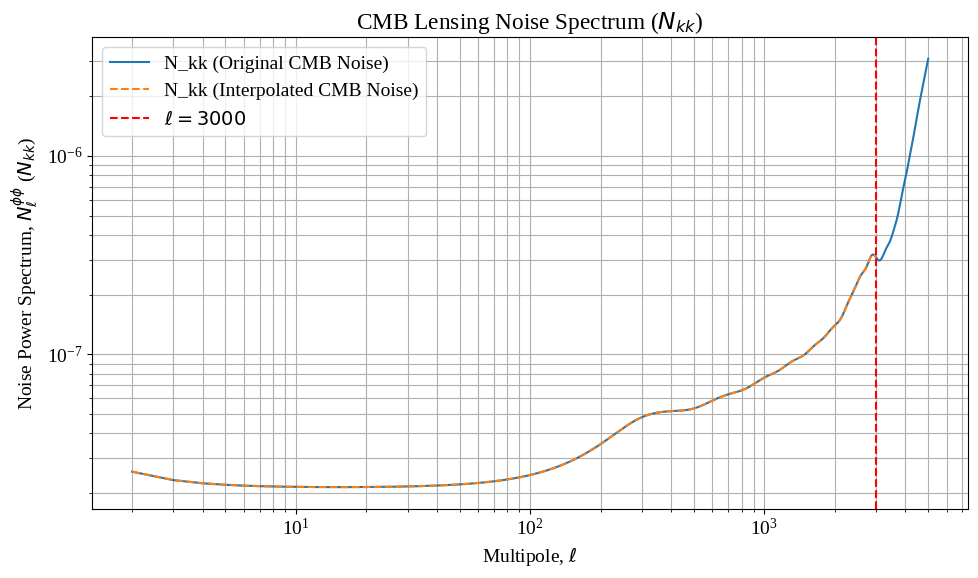

In [9]:
# plot N_kk to see what it looks like

plt.figure(figsize=(10, 6))
plt.loglog(S_noise_ells, N_kk, label='N_kk (Original CMB Noise)')
plt.loglog(ells_for_noise_interp, SO_CMB_noise, label='N_kk (Interpolated CMB Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum, $N_{\ell}^{\phi\phi}$ ($N_{kk}$)')
plt.title('CMB Lensing Noise Spectrum ($N_{kk}$)')
plt.axvline(x=3000, color='red', linestyle='--', label='$\ell = 3000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

In [10]:
# make and save noise and data files for just the first bin

# make sure folder exists
os.makedirs("data", exist_ok=True)

# data
DESI_lens_data_bin1 = DESI_lens_data[:, :2]  # z + first lens bin
HSC_dist_0_3_bin1 = HSC_dist_0_3[:, :2]       # z + first source bin

# noise
DESI_shot_noise_bin1 = np.array([DESI_shot_noise[0]])
DESI_shape_noise_bin1 = np.array([DESI_shape_noise[0]])
#SO_CMB_noise was already saved

# save
np.save("data/DESI_lens_data_bin1.npy", DESI_lens_data_bin1)
np.save("data/HSC_dist_0_3_bin1.npy", HSC_dist_0_3_bin1)
np.save("data/DESI_shot_noise_bin1.npy", DESI_shot_noise_bin1)
np.save("data/DESI_shape_noise_bin1.npy", DESI_shape_noise_bin1)
#SO_CMB_noise was already saved
    
# check
print("DESI_lens_data_bin1 shape:", DESI_lens_data_bin1.shape)
print("HSC_dist_0_3_bin1 shape:", HSC_dist_0_3_bin1.shape)
print("DESI_shot_noise_bin1:", DESI_shot_noise_bin1)
print("DESI_shape_noise_bin1:", DESI_shape_noise_bin1)
print("SO_CMB_noise:", SO_CMB_noise)

DESI_lens_data_bin1 shape: (293, 2)
HSC_dist_0_3_bin1 shape: (1000, 2)
DESI_shot_noise_bin1: [3.71938241e-06]
DESI_shape_noise_bin1: [2.51430251e-07]
SO_CMB_noise: [2.566829e-08 2.327497e-08 2.244052e-08 ... 3.078634e-07 3.076747e-07
 3.074863e-07]


In [11]:
# calculate and save fiducial data vector and covariance matrix for single bin (A_s)

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 3000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=None,
        boost_emulator=None
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/single_bin_data_vector_A_s_version.npy'
covariance_filename = 'cobaya_data/single_bin_covariance_matrix_A_s_version.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

#plot_covariance_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])
#plot_correlation_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])

Calculating fiducial data vector and covariance matrix for single bin...
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
Fiducial data vector saved to: cobaya_data/single_bin_data_vector_As_version.npy
Covariance matrix saved to: cobaya_data/single_bin_covariance_matrix_As_version.npy


In [11]:
# calculate and save fiducial data vector and covariance matrix for single bin (A_s) w/emulator

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin...")

# Use explicit parameters for fiducial cosmology, avoiding dependency on info_single_bin
# These values are taken from the 'fiducial_cosmology_params' in the original 'info' dict (cell 93e8009f)
fiducial_cosmology = ccl.Cosmology(
    Omega_c=0.27,
    Omega_b=0.045,
    h=0.674,
    A_s=2.105e-9,
    n_s=0.96,
    w0=-1.0,
    wa=0.0,
    Omega_k=0.0,
    transfer_function='boltzmann_camb'
)

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
n_ell = 3000
binsize = 50
magnification_bias_lenses = 0.8
desired_spectra = ['GG', 'LL', 'GL', 'CC', 'CL', 'CG']

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        fiducial_cosmology,
        DESI_lens_data_bin1,
        HSC_dist_0_3_bin1,
        f_sky=f_sky,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=DESI_shot_noise_bin1,
        shape_noise_source=DESI_shape_noise_bin1,
        cmb_noise_phi=SO_CMB_noise, 
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=desired_spectra,
        linear_emulator=lin_emu,
        boost_emulator=boost_emu
    )

# extract and flatten the fiducial data vector
observed_data_vector = np.array([])
num_binned_ells = int(np.ceil(n_ell / binsize))

for pair in f_map.pairs:
    unbinned_cls = fiducial_spectra_dict[pair]
    binned_cls_for_pair = []
    for i in range(0, n_ell, binsize):
        end_idx = min(i + binsize, len(unbinned_cls))
        if i < end_idx:
            binned_cls_for_pair.append(np.mean(unbinned_cls[i:end_idx]))
        else:
            binned_cls_for_pair.append(0.0)
    while len(binned_cls_for_pair) < num_binned_ells:
        binned_cls_for_pair.append(0.0)
    observed_data_vector = np.concatenate((observed_data_vector, binned_cls_for_pair))

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# Save to files
data_vector_filename = 'cobaya_data/emulated_single_bin_data_vector.npy'
covariance_filename = 'cobaya_data/emulated_single_bin_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

print(f"Fiducial data vector saved to: {data_vector_filename}")
print(f"Covariance matrix saved to: {covariance_filename}")

#plot_covariance_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])
#plot_correlation_matrix(cov_obj, fiducial_spectra_dict, f_map, binsize=50, desired_spectra=['CG', 'GL'])

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Calculating fiducial data vector and covariance matrix for single bin...
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
Fiducial data vector saved to: cobaya_data/emulated_single_bin_data_vector.npy
Covariance matrix saved to: cobaya_data/emulated_single_bin_covariance_matrix.npy


## Cobaya

1.  **Parameters**: The cosmological parameters we want to constrain (e.g., $\Omega_m$, $\sigma_8$, $h$).
2.  **Likelihood**: A Python class that calculates the log-likelihood $L(\mathbf{D}|\mathbf{\theta})$, where $\mathbf{D}$ is the data vector and $\mathbf{\theta}$ are the cosmological parameters. For a Gaussian likelihood, this involves comparing a theoretical model (based on $\mathbf{\theta}$) to an observed data vector (which we'll treat as a fiducial model with noise) and using a covariance matrix.
3.  **Prior**: The prior distributions for our parameters.
4.  **Sampler**: The MCMC algorithm Cobaya will use to explore the parameter space.

### Likelihood

$$\ln L = -\frac{1}{2} (\mathbf{D} - \mathbf{M}(\mathbf{\theta}))^T \mathbf{C}^{-1} (\mathbf{D} - \mathbf{M}(\mathbf{\theta})) - \frac{1}{2} \ln |\mathbf{C}|$$

where:
*   $\mathbf{D}$ is the 'observed' data vector (derived from a fiducial cosmology with noise).
*   $\mathbf{M}(\mathbf{\theta})$ is the model prediction for the data vector, calculated using the given cosmological parameters $\mathbf{\theta}$.
*   $\mathbf{C}$ is the covariance matrix.

We already have the infrastructure to build the covariance matrix and calculate the theoretical $C_\ell$ values for a given cosmology. Now, we need to wrap this logic into a Cobaya-compatible likelihood class.

### Parameters and Sampler

**Parameters (params section):**

*   **prior**: The prior distribution for the parameter (e.g., min/max for a flat prior, loc/scale for a Gaussian).
*   **ref**: A reference value, often used by samplers to initiate chains or define a starting point.
*   **proposal**: The width of the proposal distribution for the sampler (how much the parameter changes in each step).
*   **latex**: A LaTeX representation for plotting and reporting.

**Sampler (sampler section):**

*   **Rminus1_stop**: A convergence criterion (Gelman-Rubin statistic minus 1). Smaller values indicate better convergence.
*   **max_samples**: The maximum number of samples to generate.



In [ ]:
# Cobaya from Jupyter

In [ ]:
# bin1 one param -- omega_m
# have yaml file call these data and niose and covariances files
# then run cobaya!
# single bin single param (omega_m)
t0 = time.time()
yaml_filename = 'yaml/bin1_omega_m_likelihood_sigma8_version.yaml'
print(f"Running Cobaya sampler from YAML file: {yaml_filename}")
updated_info_from_yaml, sampler_from_yaml = cobaya_run(yaml_filename)
print("Cobaya run from YAML completed.")
tf = time.time()
time = tf - t0
print(f"Run time: {time:.4f}")

Running Cobaya sampler from YAML file: yaml/bin1_omega_m_likelihood_sigma8_version.yaml
[output] Output to be read-from/written-into folder 'chains', with prefix 'cobaya_so_x_desi_forecast_bin1_omega_m_sigma8_version_w_noise'
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/single_bin_data_vector_sigma8_version.npy
  Loading covariance matrix from: cobaya_data/single_bin_covariance_matrix_sigma8_version.npy
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
SO_x_DESI_Likelihood initialized successfully.
[mcmc] Getting initial point... (this may take a few seconds)
[mcmc] Initial point: Omega_m:0.315
[model] Measuring speeds... (this m

In [ ]:
# bin1 one param -- omega_m
# have yaml file call these data and niose and covariances files
# then run cobaya!
# single bin single param (omega_m)
t0 = time.time()
yaml_filename = 'yaml/bin1_omega_m_likelihood_sigma8_version.yaml'
print(f"Running Cobaya sampler from YAML file: {yaml_filename}")
updated_info_from_yaml, sampler_from_yaml = cobaya_run(yaml_filename)
print("Cobaya run from YAML completed.")
tf = time.time()
time = tf - t0
print(f"Run time: {time:.4f}")

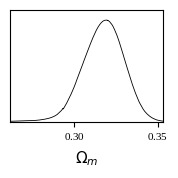

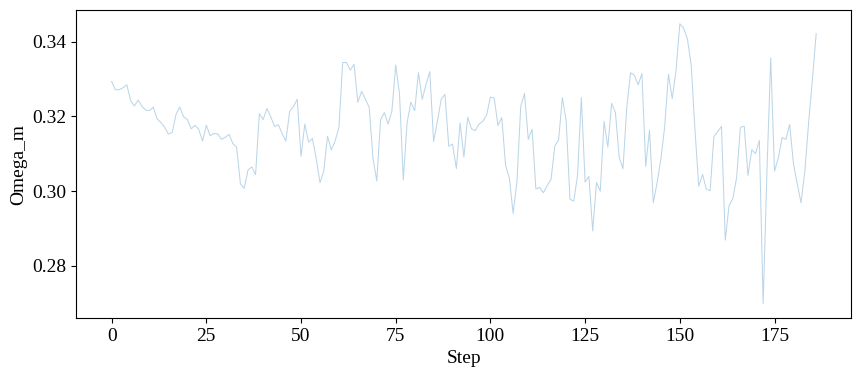

In [14]:
# plot distribution and trace

# distribution
samples = loadMCSamples("chains/cobaya_so_x_desi_forecast_bin1_omega_m_sigma8_version_w_noise")

g = plots.get_subplot_plotter()
g.plot_1d(samples, 'Omega_m')
ax = plt.gca()

# trace
plt.figure(figsize=(10, 4))
chain = np.loadtxt("chains/cobaya_so_x_desi_forecast_bin1_omega_m_sigma8_version_w_noise.1.txt")
omega_m = chain[:, 2]  # adjust index if Omega_m isn't first column

burn = int(0.2 * len(omega_m))
plt.plot(omega_m[burn:], alpha=0.3, linewidth=0.75)
plt.xlabel("Step")
plt.ylabel("Omega_m")
plt.show()
plt.show()

All parameters in chain:
['Omega_m', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__functions_and_classes.SO_x_DESI_Likelihood_sigma8_version']


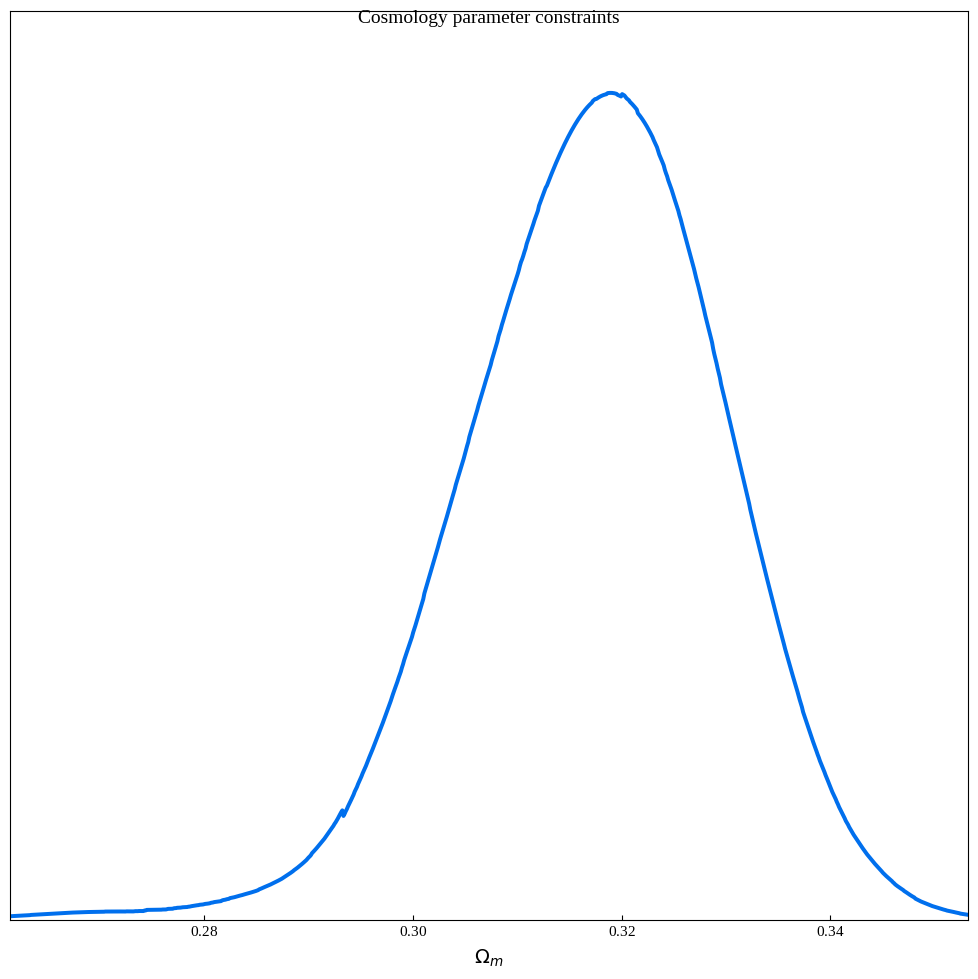

In [15]:
# corner plot

# load emulator chains (prefix only)
chain_output_path = 'chains/cobaya_so_x_desi_forecast_bin1_omega_m_sigma8_version_w_noise'
samples = loadMCSamples(chain_output_path)

# find available parameters
param_infos = samples.getParamNames().names
param_names = [p.name for p in param_infos]

print("All parameters in chain:")
print(param_names)

# cosmology parameters
cosmo_params = ['Omega_m']

# keep only ones that actually exist in the chain
cosmo_params = [p for p in cosmo_params if p in param_names]

# make triangle plot
g = plots.get_subplot_plotter(width_inch=10)
g.triangle_plot(samples, params=cosmo_params, filled=True, linewidth=1, color='black')

plt.suptitle("Cosmology parameter constraints", fontsize=14)
plt.show()

In [ ]:
# Cobaya in NERSC Configured Job
# 1 node, 4 tasks per node, 64 CPUs per task

In [ ]:
Syntax: 

cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/XXXXXXXXXX.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

mkdir -p chains/XXXXXXXXXXXXXXXXX
cd ~/DESIxSO/chains/XXXXXXXXXXXXXXXXX

for i in {0..3}; do
  cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt ~/DESIxSO/chains/XXXXXXXXXXXXXXXXX/chain_task_${i}.txt
  ln -sf chain_task_${i}.txt cosmo_run.$((i)).txt
done

cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames ~/DESIxSO/chains/XXXXXXXXXXXXXXXXX/cosmo_run.paramnames

In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/emulated_bin1_omega_m_A_s_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
mkdir -p chains/emulated_bin1_omega_m_A_s_likelihood
cd ~/DESIxSO/chains/emulated_bin1_omega_m_A_s_likelihood

for i in {0..3}; do
  cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt ~/DESIxSO/chains/emulated_bin1_omega_m_A_s_likelihood/chain_task_${i}.txt
  ln -sf chain_task_${i}.txt cosmo_run.$((i)).txt
done

cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames ~/DESIxSO/chains/emulated_bin1_omega_m_A_s_likelihood/cosmo_run.paramnames

Results for sigma8 non-emulated MCMC:
Runtime: 14 min

The peak of the Omega_m distribution is at: 0.3159


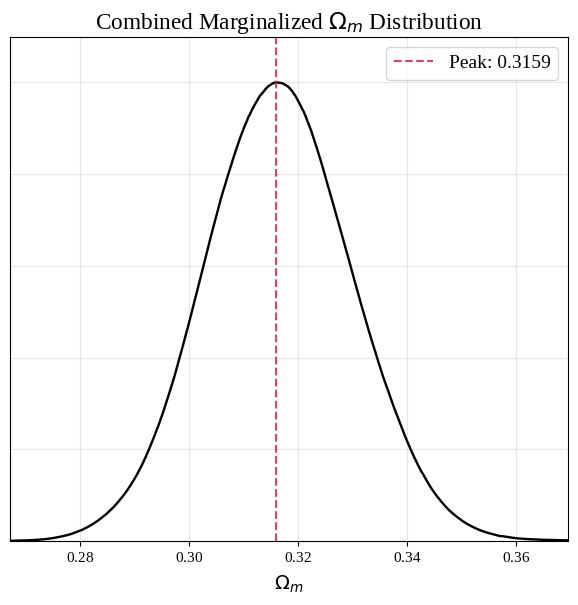

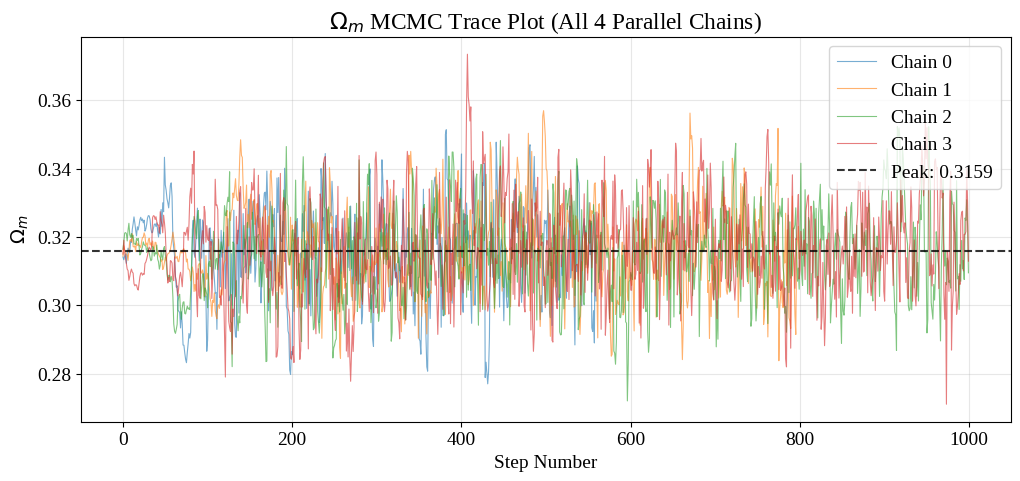

In [15]:
# plot results for sigma8 non-emulated version
print("Results for sigma8 non-emulated MCMC:")
print("Runtime: 14 min")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/bin1_omega_m_likelihood_sigma8_version')

all_samples = []
all_weights = []
all_loglikes = []

# loop through 4 raw task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # Apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_samples.append(data[burn:, 2]) # Index 2 tracks Omega_m

# combine and create the MCSamples object
samples = MCSamples(
    samples=np.concatenate(all_samples),
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m'],
    labels=[r'\Omega_m'],
    settings={'ignore_rows': 0.0}
)

# get the 1D density estimator for Omega_m and find its peak location
density1D = samples.get1DDensity('Omega_m')
omega_m_peak = density1D.x[np.argmax(density1D.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")

# combined Marginalized Distribution Plot with Peak Line
g1 = plots.get_subplot_plotter(width_inch=6)
g1.plot_1d(samples, 'Omega_m', LineWidth=2, color='darkblue')
plt.axvline(x=omega_m_peak, color='crimson', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.title(r'Combined Marginalized $\Omega_m$ Distribution')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
g1.export('plots/MCMC_runs/traces_and_dists/non-bin1_omega_m_triangle_plot_(sigma8_version).pdf')
plt.show()

# plot traces
plt.figure(figsize=(12, 5))
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        plt.plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
plt.axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.xlabel('Step Number')
plt.ylabel(r'$\Omega_m$')
plt.title(r'$\Omega_m$ MCMC Trace Plot (All 4 Parallel Chains)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.savefig('plots/MCMC_runs/traces_and_dists/bin1_omega_m_traces_(sigma8_version).png', dpi=300, bbox_inches='tight')
plt.show()

Results for A_s non-emulated MCMC:
Runtime: 13 min 3 sec
[mcmc] Learn + convergence test @ 1000 samples accepted.
[mcmc]  - Acceptance rate: 0.574
[mcmc]  - Convergence of means: R-1 = 0.012309 after 800 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Reached maximum number of accepted steps allowed (1000). Stopping.
[mcmc] Sampling complete after 1000 accepted steps.

The peak of the Omega_m distribution is at: 0.3148


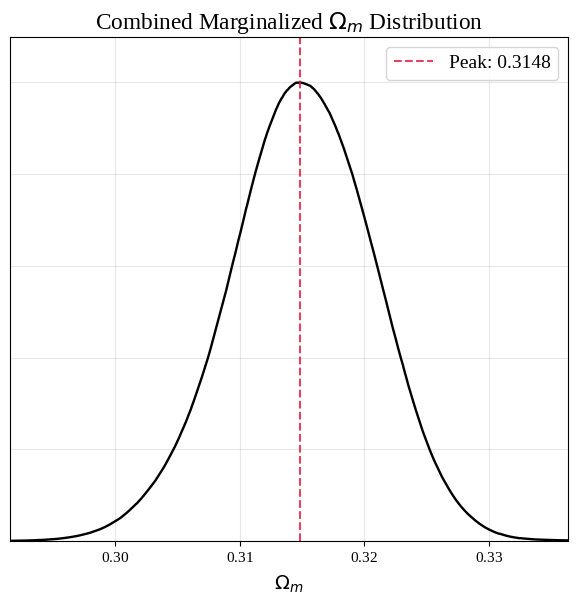

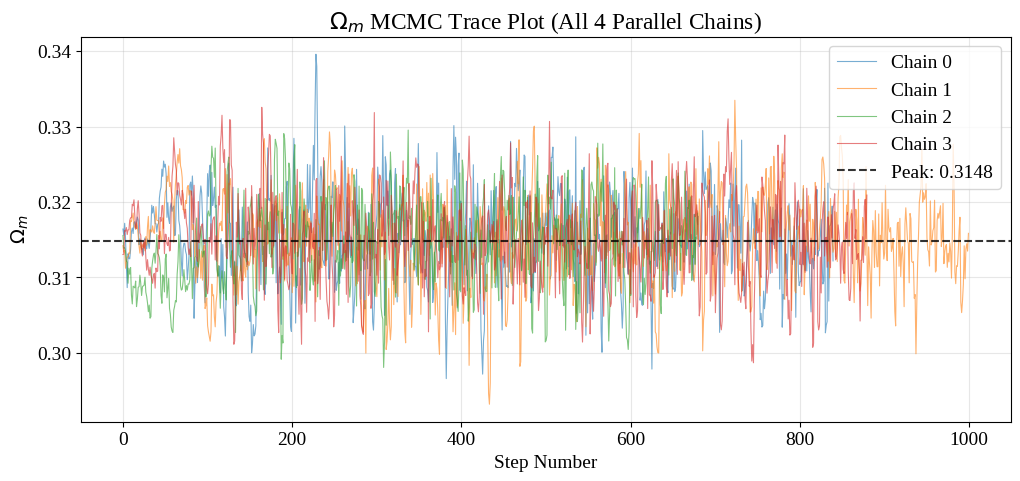

In [14]:
# plot results for A_s non-emulated version
print("Results for A_s non-emulated MCMC:")
print("Runtime: 13 min 3 sec")
print("[mcmc] Learn + convergence test @ 1000 samples accepted.")
print("[mcmc]  - Acceptance rate: 0.574")
print("[mcmc]  - Convergence of means: R-1 = 0.012309 after 800 accepted steps")
print("[mcmc]  - Updated covariance matrix of proposal pdf.")
print("[mcmc] Reached maximum number of accepted steps allowed (1000). Stopping.")
print("[mcmc] Sampling complete after 1000 accepted steps.")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/bin1_omega_m_likelihood_A_s_version')

all_samples = []
all_weights = []
all_loglikes = []

# loop through 4 raw task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # Apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_samples.append(data[burn:, 2]) # Index 2 tracks Omega_m

# combine and create the MCSamples object
samples = MCSamples(
    samples=np.concatenate(all_samples),
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m'],
    labels=[r'\Omega_m'],
    settings={'ignore_rows': 0.0}
)

# get the 1D density estimator for Omega_m and find its peak location
density1D = samples.get1DDensity('Omega_m')
omega_m_peak = density1D.x[np.argmax(density1D.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")

# combined Marginalized Distribution Plot with Peak Line
g1 = plots.get_subplot_plotter(width_inch=6)
g1.plot_1d(samples, 'Omega_m', LineWidth=2, color='darkblue')
plt.axvline(x=omega_m_peak, color='crimson', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.title(r'Combined Marginalized $\Omega_m$ Distribution')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
g1.export('plots/MCMC_runs/traces_and_dists/non-emulated_bin1_omega_m_triangle_plot_(incomplete).pdf')
plt.show()

# plot traces
plt.figure(figsize=(12, 5))
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        plt.plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
plt.axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.xlabel('Step Number')
plt.ylabel(r'$\Omega_m$')
plt.title(r'$\Omega_m$ MCMC Trace Plot (All 4 Parallel Chains)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.savefig('plots/MCMC_runs/traces_and_dists/non-emulated_bin1_omega_m_traces_(incomplete).png', dpi=300, bbox_inches='tight')
plt.show()

Results for A_s emulated MCMC:
Runtime: 16 min 30 sec
[mcmc] Reached maximum number of accepted steps allowed (1500). Stopping.
[mcmc] Sampling complete after 1500 accepted steps.
[mcmc] Learn + convergence test @ 1480 samples accepted.
[mcmc]  - Acceptance rate: 0.610
[mcmc]  - Convergence of means: R-1 = 0.005018 after 1184 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Reached maximum number of accepted steps allowed (1500). Stopping.
[mcmc] Sampling complete after 1500 accepted steps.

The peak of the Omega_m distribution is at: 0.3156


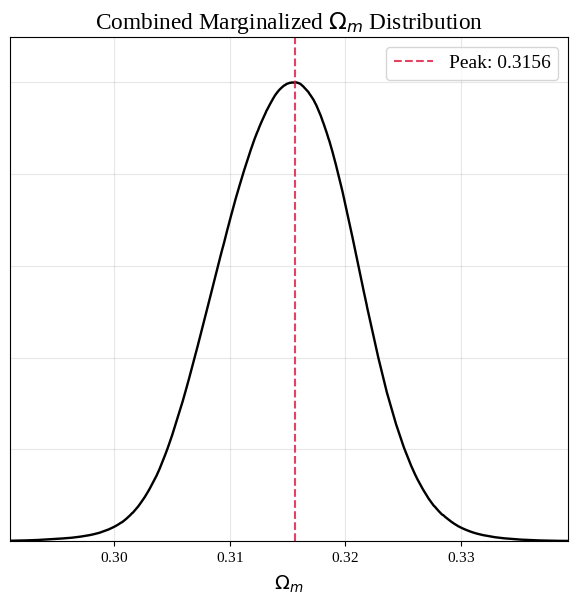

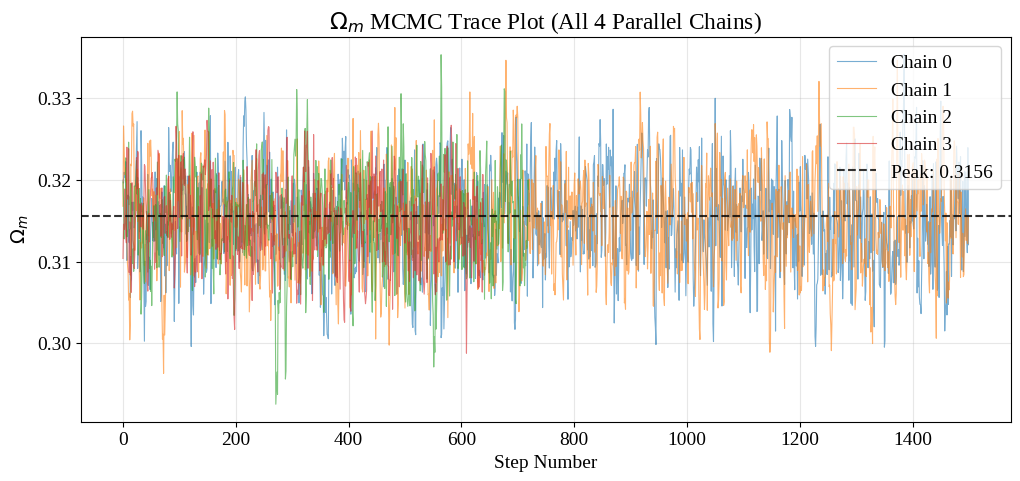

In [13]:
# plot results for A_s emulated version
print("Results for A_s emulated MCMC:")
print("Runtime: 16 min 30 sec")
print("[mcmc] Reached maximum number of accepted steps allowed (1500). Stopping.")
print("[mcmc] Sampling complete after 1500 accepted steps.")
print("[mcmc] Learn + convergence test @ 1480 samples accepted.")
print("[mcmc]  - Acceptance rate: 0.610")
print("[mcmc]  - Convergence of means: R-1 = 0.005018 after 1184 accepted steps")
print("[mcmc]  - Updated covariance matrix of proposal pdf.")
print("[mcmc] Reached maximum number of accepted steps allowed (1500). Stopping.")
print("[mcmc] Sampling complete after 1500 accepted steps.")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_bin1_omega_m_likelihood')

all_samples = []
all_weights = []
all_loglikes = []

# loop through 4 raw task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # Apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_samples.append(data[burn:, 2]) # Index 2 tracks Omega_m

# combine and create the MCSamples object
samples = MCSamples(
    samples=np.concatenate(all_samples),
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m'],
    labels=[r'\Omega_m'],
    settings={'ignore_rows': 0.0}
)

# get the 1D density estimator for Omega_m and find its peak location
density1D = samples.get1DDensity('Omega_m')
omega_m_peak = density1D.x[np.argmax(density1D.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")

# combined Marginalized Distribution Plot with Peak Line
g1 = plots.get_subplot_plotter(width_inch=6)
g1.plot_1d(samples, 'Omega_m', LineWidth=2, color='darkblue')
plt.axvline(x=omega_m_peak, color='crimson', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.title(r'Combined Marginalized $\Omega_m$ Distribution')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
g1.export('plots/MCMC_runs/traces_and_dists/emulated_bin1_omega_m_triangle_plot_(incomplete).pdf')
plt.show()

# plot traces
plt.figure(figsize=(12, 5))
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        plt.plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
plt.axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
plt.xlabel('Step Number')
plt.ylabel(r'$\Omega_m$')
plt.title(r'$\Omega_m$ MCMC Trace Plot (All 4 Parallel Chains)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_bin1_omega_m_traces_(incomplete).png', dpi=300, bbox_inches='tight')
plt.show()

Results for less-accurate (0.02 stop) 1-bin emulated MCMC sampling over omega_m and A_s:
[mcmc] The run has converged!
[mcmc] Sampling complete after 1360 accepted steps.
Runtime: 15 min 1 sec

The peak of the Omega_m distribution is at: 0.3103
The peak of the A_s distribution is at: 2.0427e-09


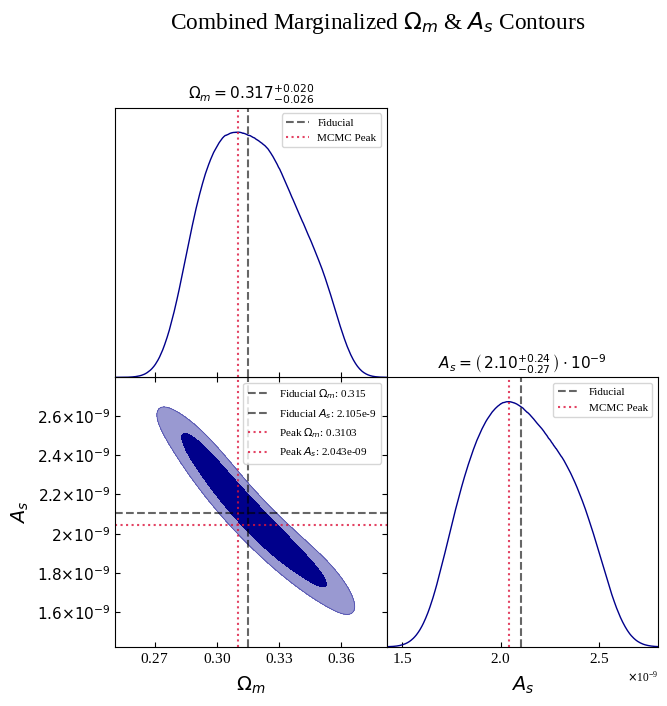

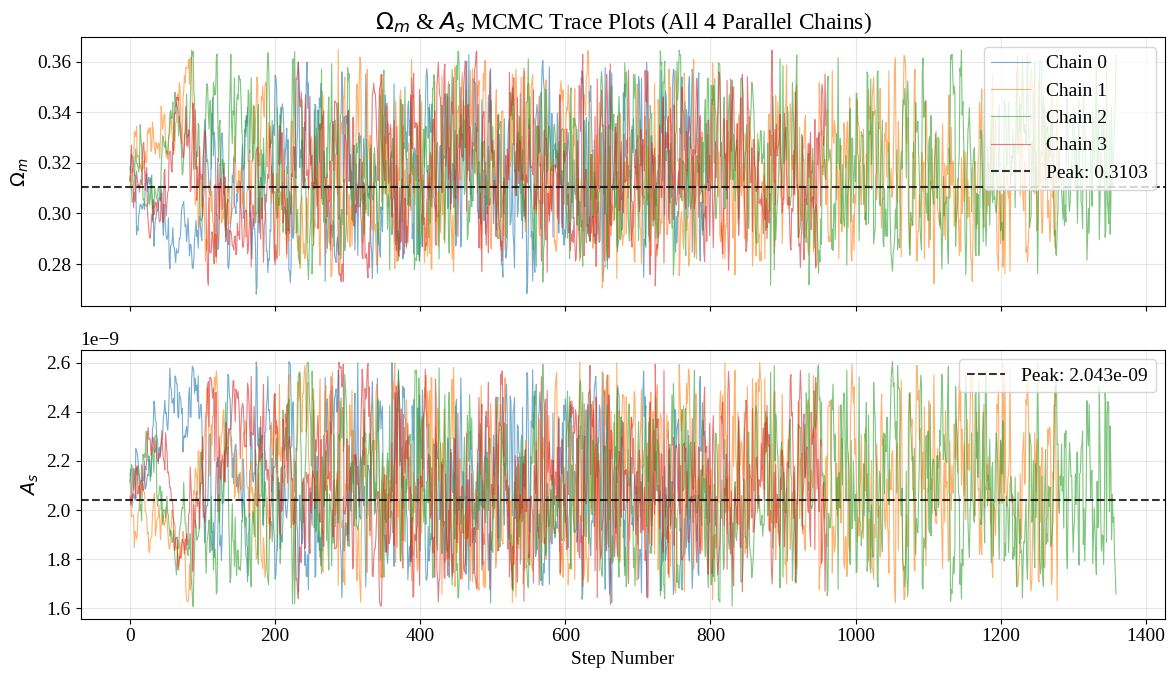

In [12]:
# plot results for emulated omega_m and A_s sampling
print("Results for less-accurate (0.02 stop) 1-bin emulated MCMC sampling over omega_m and A_s:")
print("[mcmc] The run has converged!")
print("[mcmc] Sampling complete after 1360 accepted steps.")
print("Runtime: 15 min 1 sec")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_bin1_omega_m_A_s_likelihood_.02_stop')
all_weights = []
all_loglikes = []
all_omega_m = []
all_A_s = []

# loop through the 4 raw MPI task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_omega_m.append(data[burn:, 2])  # Index 2 tracks Omega_m
        all_A_s.append(data[burn:, 3])      # Index 3 tracks A_s

# combine the separated tracks into an (N, 2) array for MCSamples
combined_samples = np.column_stack((
    np.concatenate(all_omega_m),
    np.concatenate(all_A_s)
))

# combine and create the 2D MCSamples object
samples = MCSamples(
    samples=combined_samples,
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m', 'A_s'],
    labels=[r'\Omega_m', r'A_s'],
    settings={'ignore_rows': 0.0}
)

# find 1D peak positions for annotations
density1D_om = samples.get1DDensity('Omega_m')
omega_m_peak = density1D_om.x[np.argmax(density1D_om.P)]

density1D_as = samples.get1DDensity('A_s')
A_s_peak = density1D_as.x[np.argmax(density1D_as.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")
print(f"The peak of the A_s distribution is at: {A_s_peak:.4e}")

g1 = plots.get_subplot_plotter(width_inch=7)
g1.triangle_plot(
    [samples], 
    params=['Omega_m', 'A_s'], 
    filled=True, 
    contour_colors=['darkblue'],
    title_limit=1,
)
                
# Add crosshairs for the true fiducial values and the MCMC peaks
if len(g1.subplots) > 1:
    if g1.subplots[0, 0] is not None:
        g1.subplots[0, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[0, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[0, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 0] is not None:
        # True Fiducial Crosshairs (Dashed Black Bullseye)
        g1.subplots[1, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial $\Omega_m$: 0.315')
        g1.subplots[1, 0].axhline(y=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial $A_s$: 2.105e-9')        
        # MCMC Peak Crosshairs (Dotted Crimson)
        g1.subplots[1, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $\Omega_m$: {omega_m_peak:.4f}')
        g1.subplots[1, 0].axhline(y=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $A_s$: {A_s_peak:.3e}')
        g1.subplots[1, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 1] is not None:
        g1.subplots[1, 1].axvline(x=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[1, 1].axvline(x=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[1, 1].legend(loc='upper right', fontsize=8)

g1.export('plots/MCMC_runs/traces_and_dists/less_acc_emulated_bin1_omega_m_A_s_triangle_plot.pdf')
plt.suptitle(r'Combined Marginalized $\Omega_m$ & $A_s$ Contours', y=1.02)
plt.show()

# traces
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        
        # Panel 1: Omega_m trace
        axes[0].plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
        # Panel 2: A_s trace
        axes[1].plot(chain_data[:, 3], alpha=0.6, linewidth=0.8)

# Add benchmark lines to traces
axes[0].axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
axes[0].set_ylabel(r'$\Omega_m$')
axes[0].set_title(r'$\Omega_m$ & $A_s$ MCMC Trace Plots (All 4 Parallel Chains)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=A_s_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {A_s_peak:.3e}')
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel(r'$A_s$')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
plt.savefig('plots/MCMC_runs/traces_and_dists/less_acc_emulated_bin1_omega_m_A_s_traces.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Results for 1-bin emulated MCMC sampling over omega_m and A_s:
Runtime: 23 min 52 sec
[mcmc] The run has converged!
[mcmc] Sampling complete after 2240 accepted steps.

The peak of the Omega_m distribution is at: 0.3102
The peak of the A_s distribution is at: 2.0282e-09


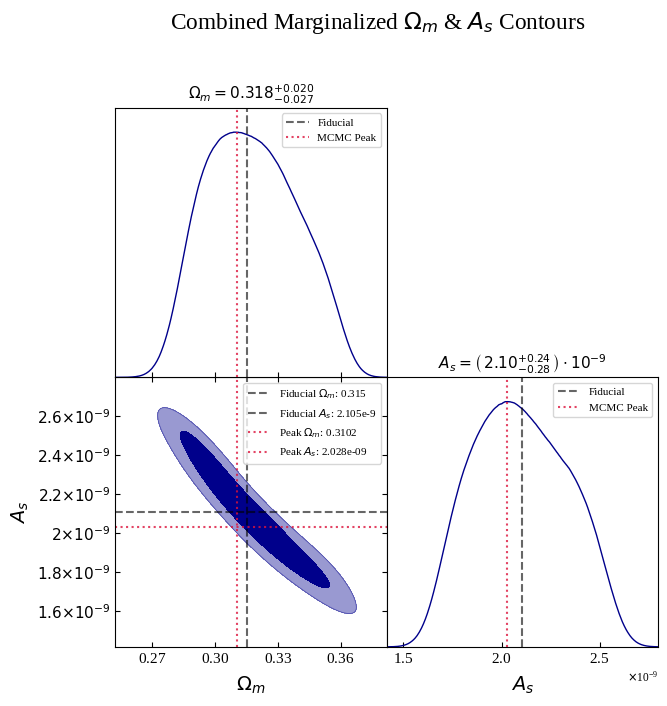

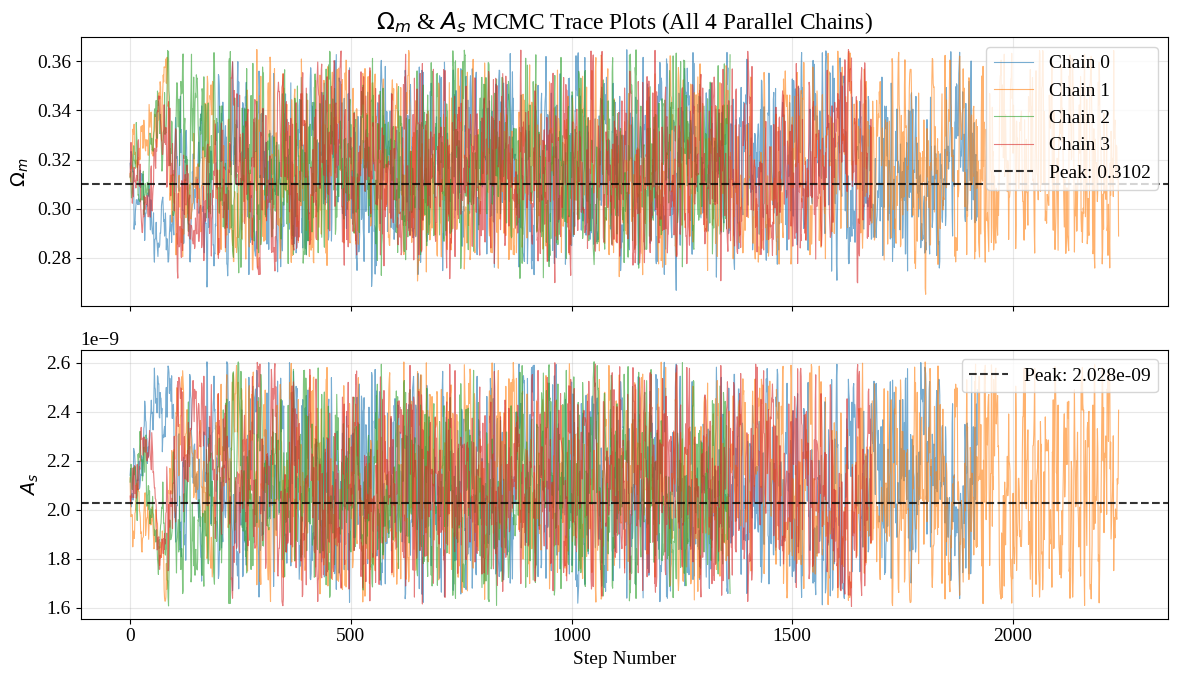

In [11]:
# plot results for emulated omega_m and A_s sampling
print("Results for 1-bin emulated MCMC sampling over omega_m and A_s:")
print("Runtime: 23 min 52 sec")
print("[mcmc] The run has converged!")
print("[mcmc] Sampling complete after 2240 accepted steps.")
print("")

chain_dir = os.path.expanduser('~/DESIxSO/chains/emulated_bin1_omega_m_A_s_likelihood')
all_weights = []
all_loglikes = []
all_omega_m = []
all_A_s = []

# loop through the 4 raw MPI task text files explicitly
for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        data = np.loadtxt(chain_path)
        
        # apply your 20% burn-in manually to each individual chain
        burn = int(0.2 * len(data))
        
        all_weights.append(data[burn:, 0])
        all_loglikes.append(data[burn:, 1])
        all_omega_m.append(data[burn:, 2])  # Index 2 tracks Omega_m
        all_A_s.append(data[burn:, 3])      # Index 3 tracks A_s

# combine the separated tracks into an (N, 2) array for MCSamples
combined_samples = np.column_stack((
    np.concatenate(all_omega_m),
    np.concatenate(all_A_s)
))

# combine and create the 2D MCSamples object
samples = MCSamples(
    samples=combined_samples,
    weights=np.concatenate(all_weights),
    loglikes=np.concatenate(all_loglikes),
    names=['Omega_m', 'A_s'],
    labels=[r'\Omega_m', r'A_s'],
    settings={'ignore_rows': 0.0}
)

# find 1D peak positions for annotations
density1D_om = samples.get1DDensity('Omega_m')
omega_m_peak = density1D_om.x[np.argmax(density1D_om.P)]

density1D_as = samples.get1DDensity('A_s')
A_s_peak = density1D_as.x[np.argmax(density1D_as.P)]

print(f"The peak of the Omega_m distribution is at: {omega_m_peak:.4f}")
print(f"The peak of the A_s distribution is at: {A_s_peak:.4e}")

g1 = plots.get_subplot_plotter(width_inch=7)
g1.triangle_plot(
    [samples], 
    params=['Omega_m', 'A_s'], 
    filled=True, 
    contour_colors=['darkblue'],
    title_limit=1,
)
                
# Add crosshairs for the true fiducial values and the MCMC peaks
if len(g1.subplots) > 1:
    if g1.subplots[0, 0] is not None:
        g1.subplots[0, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[0, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[0, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 0] is not None:
        # True Fiducial Crosshairs (Dashed Black Bullseye)
        g1.subplots[1, 0].axvline(x=0.315, color='black', linestyle='--', alpha=0.6, label='Fiducial $\Omega_m$: 0.315')
        g1.subplots[1, 0].axhline(y=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial $A_s$: 2.105e-9')        
        # MCMC Peak Crosshairs (Dotted Crimson)
        g1.subplots[1, 0].axvline(x=omega_m_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $\Omega_m$: {omega_m_peak:.4f}')
        g1.subplots[1, 0].axhline(y=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label=f'Peak $A_s$: {A_s_peak:.3e}')
        g1.subplots[1, 0].legend(loc='upper right', fontsize=8)
    if g1.subplots[1, 1] is not None:
        g1.subplots[1, 1].axvline(x=2.105e-9, color='black', linestyle='--', alpha=0.6, label='Fiducial')
        g1.subplots[1, 1].axvline(x=A_s_peak, color='crimson', linestyle=':', alpha=0.8, label='MCMC Peak')
        g1.subplots[1, 1].legend(loc='upper right', fontsize=8)
        
g1.export('plots/MCMC_runs/traces_and_dists/emulated_bin1_omega_m_A_s_triangle_plot.pdf')
plt.suptitle(r'Combined Marginalized $\Omega_m$ & $A_s$ Contours', y=1.02)
plt.show()

# traces
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(4):
    chain_path = os.path.join(chain_dir, f'chain_task_{i}.txt')
    if os.path.exists(chain_path):
        chain_data = np.loadtxt(chain_path)
        
        # Panel 1: Omega_m trace
        axes[0].plot(chain_data[:, 2], alpha=0.6, linewidth=0.8, label=f'Chain {i}')
        # Panel 2: A_s trace
        axes[1].plot(chain_data[:, 3], alpha=0.6, linewidth=0.8)

# Add benchmark lines to traces
axes[0].axhline(y=omega_m_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {omega_m_peak:.4f}')
axes[0].set_ylabel(r'$\Omega_m$')
axes[0].set_title(r'$\Omega_m$ & $A_s$ MCMC Trace Plots (All 4 Parallel Chains)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=A_s_peak, color='black', linestyle='--', alpha=0.8, label=f'Peak: {A_s_peak:.3e}')
axes[1].set_xlabel('Step Number')
axes[1].set_ylabel(r'$A_s$')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.savefig('plots/MCMC_runs/traces_and_dists/emulated_bin1_omega_m_A_s_traces.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_single_bin_data_vector.npy
  Loading covariance matrix from: cobaya_data/emulated_single_bin_covariance_matrix.npy
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
SO_x_DESI_Likelihood initialized successfully.
Starting grid scan...
[jax._src.xla_bridge] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
--- Debugging Chi2 Evaluation ---
Omega_m evaluated: 0.2000 (Omega_c: 0.1550)
Total Chi2: 260.2268
--- Debugging Chi2 Eval

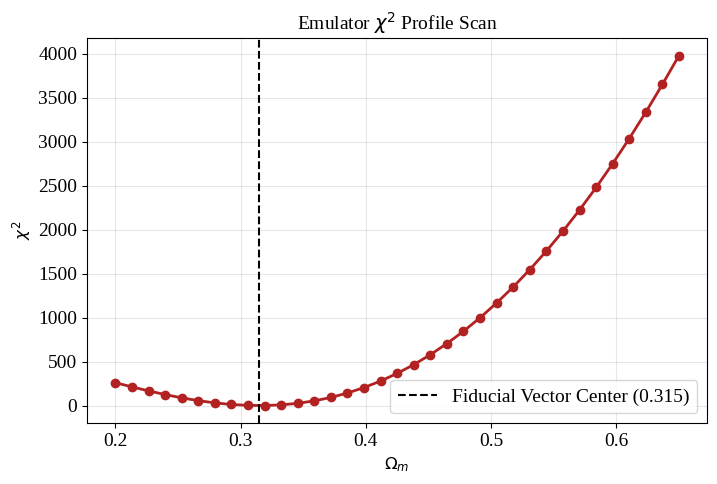

In [8]:
# get chi2 values for omega_m using emulated likelihood

info = "yaml/emulated_bin1_omega_m_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# define omega_m grid
omega_m_grid = np.linspace(0.20, 0.65, 35)
chi2_values = []

# 4. Loop through the grid and evaluate the chi2
print("Starting grid scan...")
for om in omega_m_grid:
    # pass the target parameter along with your fiducial values
    # profile_chi2 function will automatically compute Omega_c = Omega_m - Omega_b inside
    chi2 = like_object.profile_chi2(
        Omega_m=om,
        Omega_b=0.045,
        h=0.674,
        A_s=2.105e-9,
        n_s=0.96,
        w0=-1.0,
        wa=0.0,
        Omega_k=0.0
    )
    chi2_values.append(chi2)

# plot
plt.figure(figsize=(8, 5))
plt.plot(omega_m_grid, chi2_values, marker='o', color='firebrick', lw=2)
plt.axvline(0.315, color='black', linestyle='--', label='Fiducial Vector Center (0.315)')
plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$\chi^2$", fontsize=12)
plt.title(r"Emulator $\chi^2$ Profile Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

[model] *WARNING* Ignored blocks/options: ['sampler', 'output']
Initializing SO_x_DESI_Likelihood...
  Loading lens shot noise from: data/DESI_shot_noise_bin1.npy
  Loading source shape noise from: data/DESI_shape_noise_bin1.npy
  Loading CMB noise from: data/SO_CMB_noise.npy
  Loaded lens data from data/DESI_lens_data_bin1.npy
  Loaded source data from: data/HSC_dist_0_3_bin1.npy
  Loading observed data vector from: cobaya_data/emulated_single_bin_data_vector.npy
  Loading covariance matrix from: cobaya_data/emulated_single_bin_covariance_matrix.npy
[('g1', 'g1'), ('g1', 'l1'), ('g1', 'phi'), ('l1', 'l1'), ('l1', 'phi'), ('phi', 'phi')]
SO_x_DESI_Likelihood initialized successfully.
Starting 2D grid scan...
[jax._src.xla_bridge] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
--- Debugging Chi2 Evaluation ---
Omega_m evaluated: 0.2600 (Omega_c: 0.2150)
Total Chi2: 171.0434
--- Debugging Chi2 E

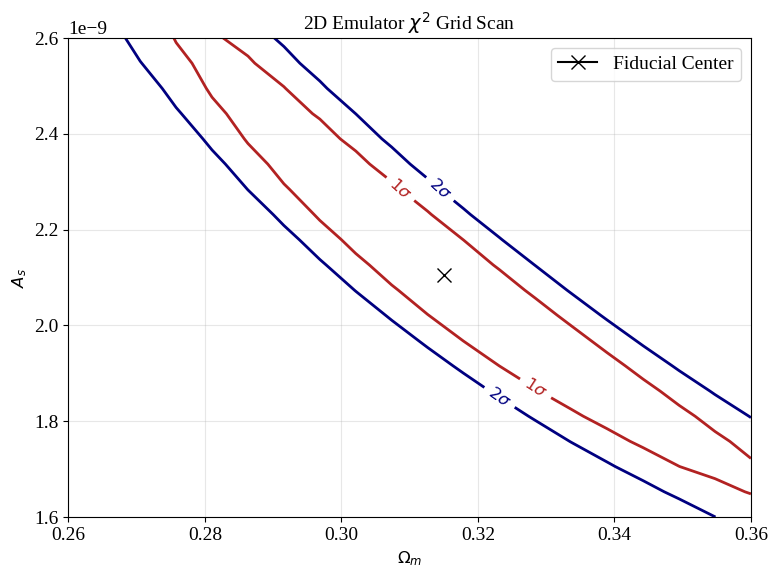

In [11]:
# 1. Initialize the model and likelihood object
info = "yaml/emulated_bin1_omega_m_A_s_likelihood.yaml"
model = get_model(info)
like_object = model.likelihood["functions_and_classes.SO_x_DESI_Likelihood_w_emulator"]

# 2. Define grids for BOTH parameters
omega_m_grid = np.linspace(0.26, 0.36, 20)
A_s_grid = np.linspace(1.6e-9, 2.6e-9, 20)

# Create empty matrix to hold chi2 values
chi2_matrix = np.zeros((len(A_s_grid), len(omega_m_grid)))

# Create a counter
step = 0
total_steps = len(A_s_grid) * len(omega_m_grid)

print("Starting 2D grid scan...")
for i, as_val in enumerate(A_s_grid):
    for j, om in enumerate(omega_m_grid):
        step += 1
        if step % 20 == 0:  # Prints an update every 20 points
            print(f"Evaluating step {step}/{total_steps}...")
            
        chi2 = like_object.profile_chi2(
            Omega_m=om,
            Omega_b=0.045,
            h=0.674,
            A_s=as_val,
            n_s=0.96,
            w0=-1.0,
            wa=0.0,
            Omega_k=0.0
        )
        chi2_matrix[i, j] = chi2

# 4. Process the Chi2 surface for plotting
min_chi2 = np.min(chi2_matrix)
delta_chi2 = chi2_matrix - min_chi2  # Delta Chi2 relative to best-fit

# 5. Plot the 2D confidence contours
plt.figure(figsize=(8, 6))

# Standard 2D Gaussian confidence intervals: 1-sigma (Delta Chi2 = 2.30), 2-sigma (Delta Chi2 = 6.18)
contour = plt.contour(omega_m_grid, A_s_grid, delta_chi2, levels=[2.30, 6.18], colors=['firebrick', 'navy'], linewidths=2)
plt.clabel(contour, inline=True, fmt={2.30: r'$1\sigma$', 6.18: r'$2\sigma$'}, fontsize=12)

# Mark the fiducial center
plt.plot(0.315, 2.105e-9, marker='x', color='black', markersize=10, label='Fiducial Center')

plt.xlabel(r"$\Omega_m$", fontsize=12)
plt.ylabel(r"$A_s$", fontsize=12)
plt.title(r"2D Emulator $\chi^2$ Grid Scan", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()